In [2]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix

In [3]:
cnx_check_views = sqlite3.connect('../../datasets/checking-logs.sqlite')
query_views = '''
SELECT uid, count(*) pageviews
FROM pageviews
WHERE uid LIKE "user_%"
GROUP BY uid
'''
pageviews = pd.read_sql(query_views, cnx_check_views)

query_checker = '''
SELECT uid, count(*) num_commits
FROM checker
WHERE uid LIKE "user_%" AND labname != "project1"
GROUP BY uid
'''
num_commits = pd.read_sql(query_checker, cnx_check_views)

query_ddl = '''
SELECT
    t.uid,
    AVG((strftime("%s", t.first_commit_ts) - d.deadlines) / 3600) AS avg_diff
FROM test t
LEFT JOIN deadlines d
    ON t.labname = d.labs
WHERE labname != "project1"
GROUP BY t.uid
'''
avg_diff = pd.read_sql(query_ddl, cnx_check_views)

print(pageviews)
print(num_commits)
print(avg_diff)
cnx_check_views.close()

        uid  pageviews
0    user_1         28
1   user_10         89
2   user_14        143
3   user_17         47
4   user_18          3
5   user_19         16
6   user_21         10
7   user_25        179
8   user_28        149
9    user_3        317
10  user_30          3
11   user_5          1
12   user_9          2
        uid  num_commits
0    user_0            3
1    user_1           62
2   user_10           20
3   user_11            7
4   user_12           86
5   user_13           52
6   user_14           61
7   user_15           23
8   user_16           41
9   user_17           51
10  user_18            5
11  user_19          118
12   user_2           46
13  user_20           57
14  user_21           65
15  user_22            5
16  user_23            6
17  user_24           37
18  user_25           79
19  user_26           36
20  user_27           27
21  user_28           60
22  user_29           51
23   user_3           18
24  user_30           34
25  user_31          128
26 

In [4]:
pivot_table = avg_diff.merge(pageviews, on="uid", how = 'inner').merge(num_commits, on="uid", how = 'inner')
pivot_table

,uid,avg_diff,pageviews,num_commits
0,user_1,-64.400000,28,62
1,user_10,-74.800000,89,20
2,user_14,-159.000000,143,61
3,user_17,-61.600000,47,51
4,user_18,-5.666667,3,5
5,user_19,-98.750000,16,118
6,user_21,-95.500000,10,65
7,user_25,-92.600000,179,79
8,user_28,-86.400000,149,60
9,user_3,-105.400000,317,18


NameError: name 'plt' is not defined

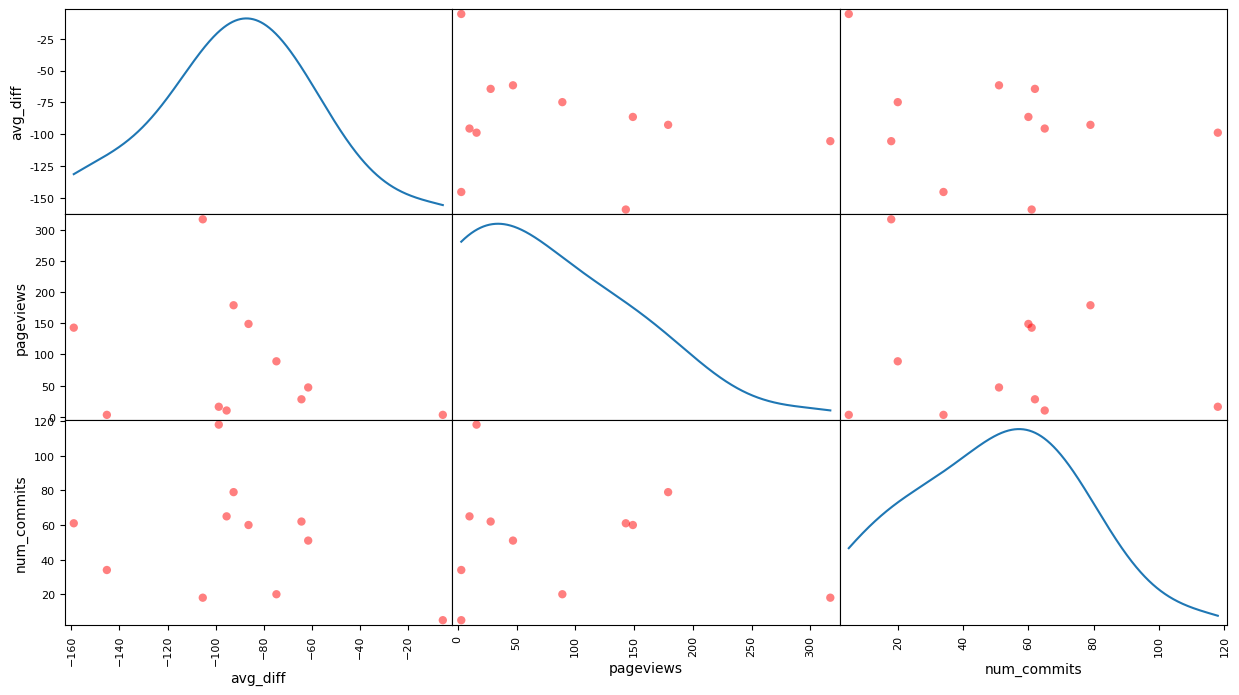

In [5]:
graph = scatter_matrix(pivot_table, figsize=[15, 8], grid = True, marker = 200, color='red', diagonal='kde')

graph

Can we say that if a user has a low number of pageviews then they likely
have a low number of commits?
- Нет


Can we say that if a user has a low number of pageviews then they likely have
a small average difference between the first commit and the lab deadline?
- Нет

Can we say that there are many users with a low number of commits and a
few with a high number of commits?
- Да

Can we say that there are many users with a small average difference and a
few with a large average difference
- Да